## Model 1 Horizontal Strtigraphy

This is a simple tutorial demonstrating how to use `GeoINR`. The geological structure consists of two horizontal layers. The observational data include `interface points` and `orientations`, where the `orientations` constrain the gradients of the predicted scalar field at the corresponding locations.

Users need to install the `geoinr_faults` package along with its dependencies: `numpy`, `pandas`, `torch`, and `pyvista`.

In [1]:
import geoinr_faults as grf

### 1. Create a geomodel
The user can define the following:
* `Project name`
* `Model range (extent)`, specified as `[x_min, x_max, y_min, y_max, z_min, z_max]`
* `Resolution`, which determines the number of voxels along each axis
* `Data path`:
* `path_to_surface_points` is required
* If orientation data are not available, you can either omit the `path_to_orientations` argument or set it to `None`

In [2]:
geomodel = grf.create_geomodel(
    project_name='Horizontal_janmodel',
    extent=[0, 1000, 0, 1000, 0, 1000],
    resolution=[50, 50, 50],
    path_to_surface_points='input_data/Horizontal_stratigraphy/horizontal_interface.csv',
    path_to_orientations='input_data/Horizontal_stratigraphy/horizontal_orientation.csv',
)

### 2. Add geological structures
* At least one stratigraphic column is required. Use the `add_stratis` function to add it.
* If faults are present, use the `add_faults` function.
* The user needs to specify the layers from the source `.csv` file using the `formation` parameter.

In [3]:
geomodel = grf.add_stratis(geomodel, strati_configs=[
    grf.StratiConfig(name="strati_A", formations=['rock2', 
                                                  'rock1']),
])

In [4]:
geomodel

GeoModel('Horizontal_janmodel', extent=[0, 1000, 0, 1000, 0, 1000], resolution=[50, 50, 50], stratis=1, horizons=[2], faults=0)

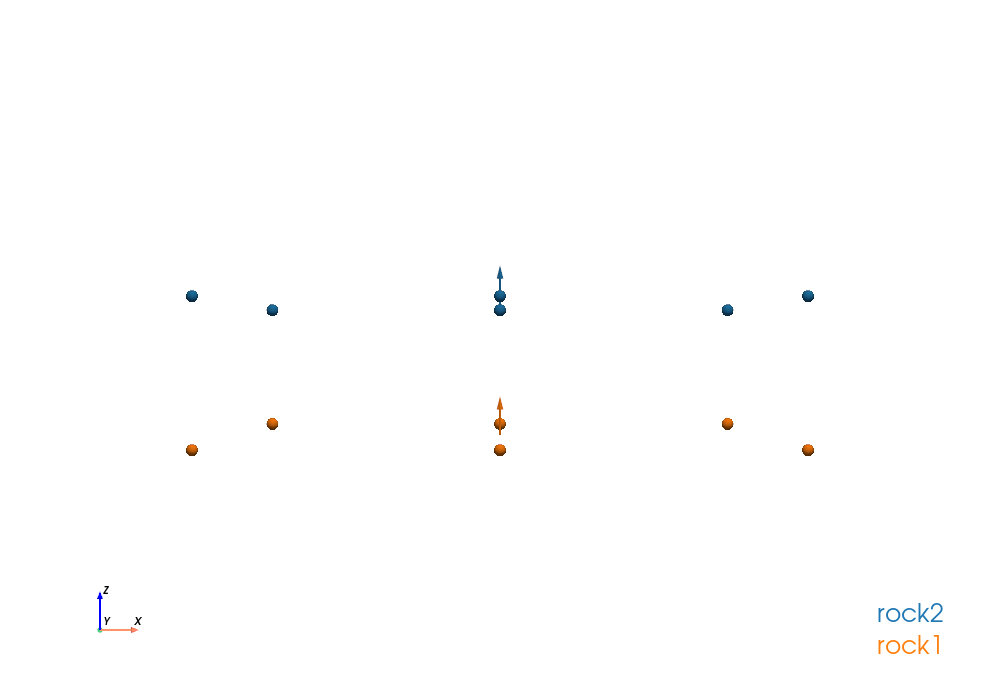

In [5]:
grf.plot_input_data(geomodel, notebook=True, legend_size=(0.1, 0.1))

### 3. Compute the model
* `nn_model`: defines the neural network architecture to use; the default is `mlp`
* `hidden_dim`: the dimensionality of the hidden layers; the default is `256`
* `n_layers`: the number of neural network layers; the default is `3`
* `activation`: the activation function; the default is `softplus`
* `softplus_beta`: the β parameter of the `softplus` activation function (only applicable when using `softplus`)
* `epochs`: the number of training iterations (forward and backward passes)
* `lr`: the learning rate
* `seed`: sets the random seed for reproducibility

In [6]:
results = grf.compute_model(
    geomodel,
    nn_model='mlp',          # 'mlp' | 'siren' | 'resnet'  or custom class
    hidden_dim=128,
    n_layers=3,
    activation='softplus',   # 'softplus' | 'relu' | 'tanh' | 'sine' | ...
    softplus_beta=5,
    epochs=1000,
    lr=1e-3,
    seed=100,
)

Epoch [500/1000]  Loss: 0.0083  Var: 0.0000  On: 0.0083  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0007
Epoch [1000/1000]  Loss: 0.0045  Var: 0.0000  On: 0.0044  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0005

Training finished in 2.0 s  |  Best loss: 0.0005
Inference completed in 0.0550 s


### 4. Visualization
Users can choose which results to visualize, including:
* `scalar field`
* `observations`
* `iso-surfaces`
* `fault surfaces`
* ...

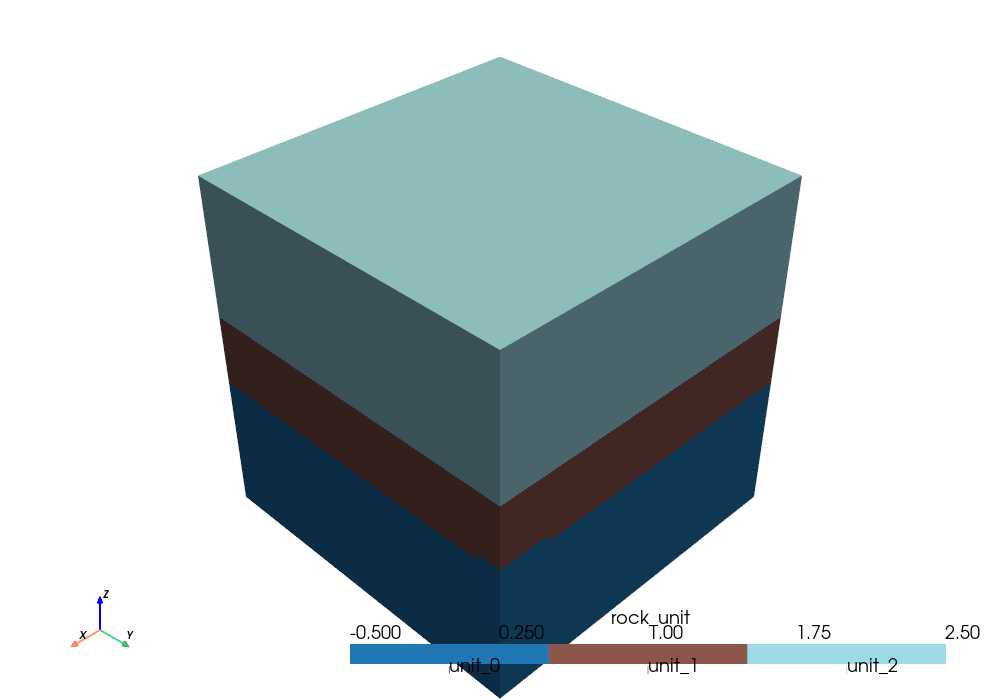

In [7]:
grf.plot_model(results, notebook=True, show_scalar_field=False, show_interface_points=True, show_rock_unit=True)

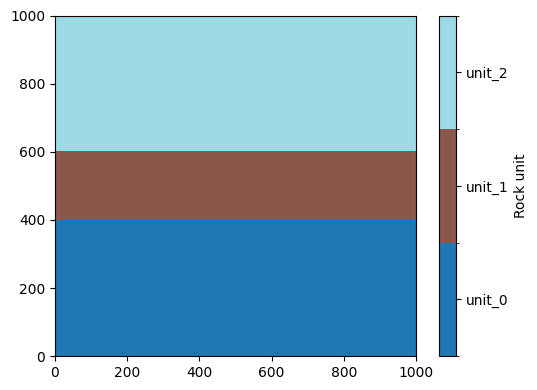

In [8]:
grf.plot_section_rock_unit(results, axis='y', figsize=(5.5, 4))